In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
!unzip archive.zip

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg 

In [4]:
import os
os.listdir("/content")

['.config', 'Testing', 'Training', 'archive.zip', 'sample_data']

In [5]:
train_path = "/content/Training"
test_path = "/content/Testing"

In [6]:
import os

tumor_types = os.listdir(train_path)
print(tumor_types)

['notumor', 'meningioma', 'glioma', 'pituitary']


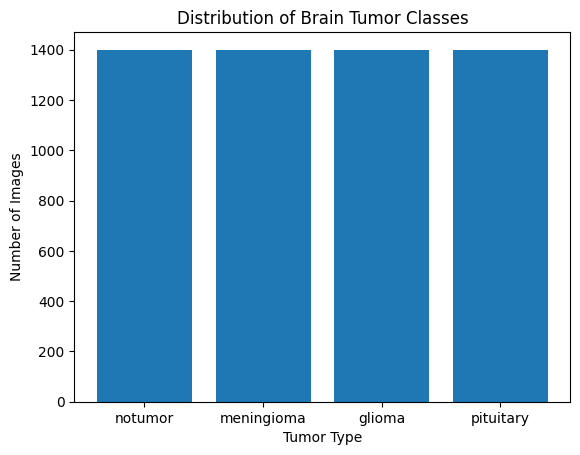

In [7]:
import matplotlib.pyplot as plt

counts = {}

for tumor_type in tumor_types:
    counts[tumor_type] = len(os.listdir(os.path.join(train_path, tumor_type)))

plt.bar(counts.keys(), counts.values())
plt.title("Distribution of Brain Tumor Classes")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.show()

In [8]:
import cv2
import numpy as np

data = []
labels = []

for tumor_type in tumor_types:

    folder = os.path.join(train_path, tumor_type)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img,(64,64))

        data.append(img)
        labels.append(tumor_type)

In [9]:
data = np.array(data)
labels = np.array(labels)

print(data.shape)

(5600, 64, 64)


In [10]:
data = data.reshape(len(data), -1)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9178571428571428


In [14]:
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img,(64,64))
img = img / 255.0

In [15]:
data = np.array(data)
labels = np.array(labels)
data = data.reshape(len(data), -1)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42)

In [17]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [18]:
from sklearn.metrics import accuracy_score

pred_rf = rf.predict(X_test)
pred_lr = lr.predict(X_test)

acc_rf = accuracy_score(y_test,pred_rf)
acc_lr = accuracy_score(y_test,pred_lr)

print(acc_rf, acc_lr)

0.9169642857142857 0.7785714285714286


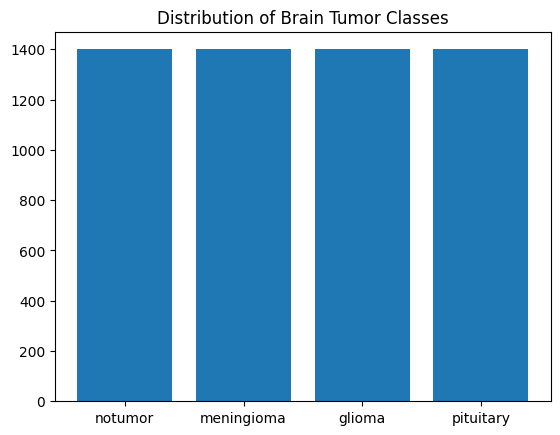

In [19]:
plt.bar(counts.keys(),counts.values())
plt.title("Distribution of Brain Tumor Classes")
plt.show()

In [ ]:
plt.imshow(img,cmap="gray")
plt.axis("off")

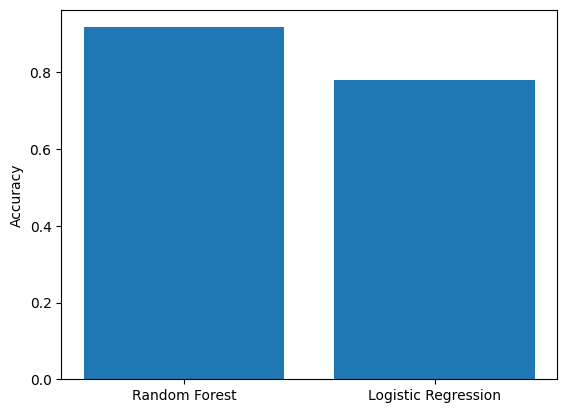

In [21]:
models=["Random Forest","Logistic Regression"]
accuracy=[acc_rf,acc_lr]

plt.bar(models,accuracy)
plt.ylabel("Accuracy")
plt.show()

<Axes: >

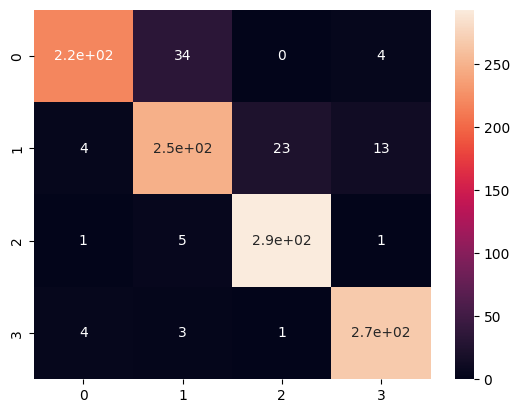

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,pred_rf)
sns.heatmap(cm,annot=True)

In [23]:
plt.savefig("figure1.png")

<Figure size 640x480 with 0 Axes>

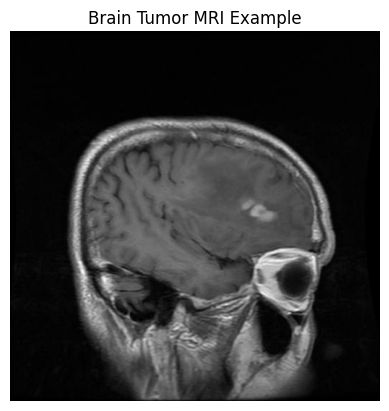

In [24]:
import cv2
import matplotlib.pyplot as plt

path = "/content/Training/glioma"

img_name = os.listdir(path)[0]
img_path = os.path.join(path, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Brain Tumor MRI Example")
plt.axis("off")
plt.show()

In [25]:
plt.savefig("brain_tumor_samples.png")

<Figure size 640x480 with 0 Axes>

In [26]:
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

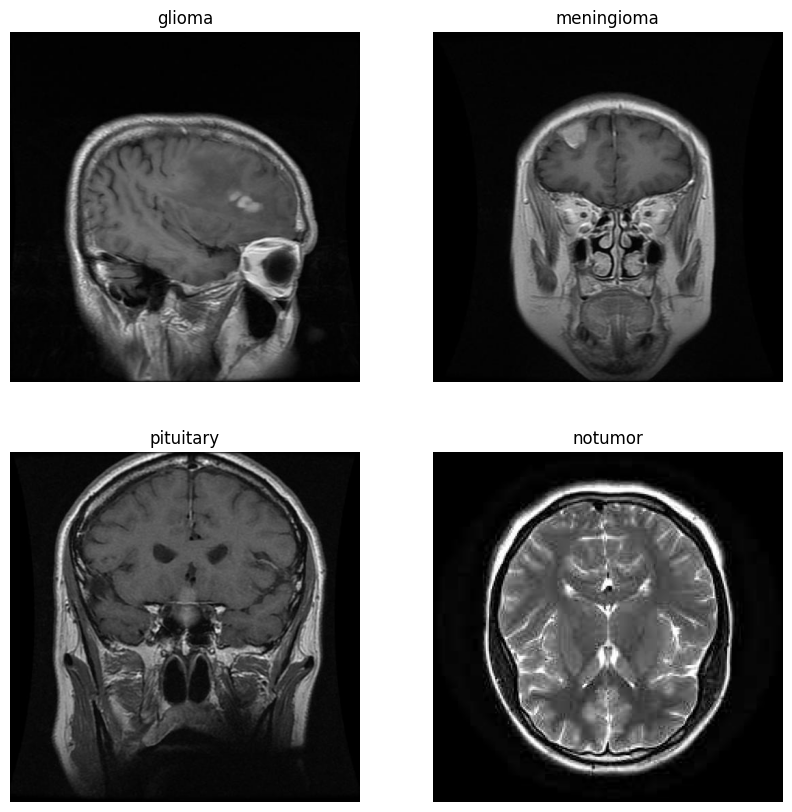

In [27]:
classes = ["glioma","meningioma","pituitary","notumor"]

plt.figure(figsize=(10,10))

for i,cls in enumerate(classes):

    path = "/content/Training/" + cls
    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

In [28]:
plt.savefig("dataset_samples.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

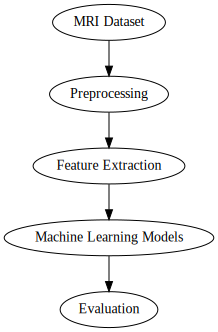

In [29]:
from graphviz import Digraph

dot = Digraph()

dot.node('A','MRI Dataset')
dot.node('B','Preprocessing')
dot.node('C','Feature Extraction')
dot.node('D','Machine Learning Models')
dot.node('E','Evaluation')

dot.edges(['AB','BC','CD','DE'])

dot

In [30]:
dataset_path = "/content/Training"

# ambil folder pertama
class_name = os.listdir(dataset_path)[0]

# ambil gambar pertama
img_path = os.path.join(dataset_path, class_name, os.listdir(os.path.join(dataset_path, class_name))[0])

img = cv2.imread(img_path)

In [31]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

resized = cv2.resize(gray, (128,128))

normalized = resized / 255.0

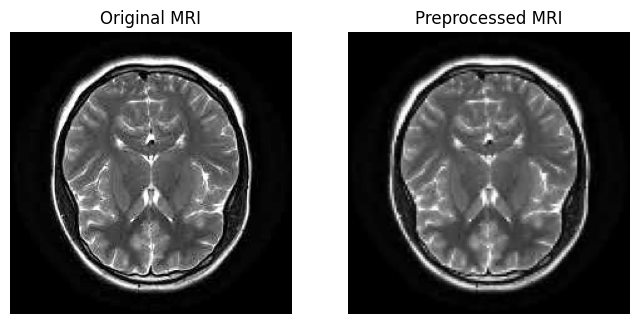

In [32]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized, cmap="gray")
plt.title("Preprocessed MRI")
plt.axis("off")

plt.show()

In [33]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred_svm = svm_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, average='weighted')
svm_rec = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

In [36]:
y_pred_svm = svm_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

In [37]:
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, average='weighted')
svm_rec = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

In [38]:
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted')
rf_rec = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

In [39]:
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

In [40]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["SVM", "Random Forest", "Logistic Regression"],
    "Accuracy": [svm_acc, rf_acc, lr_acc],
    "Precision": [svm_prec, rf_prec, lr_prec],
    "Recall": [svm_rec, rf_rec, lr_rec],
    "F1-score": [svm_f1, rf_f1, lr_f1]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.871429,0.869512,0.871429,0.869933
1,Random Forest,0.914286,0.914793,0.914286,0.913454
2,Logistic Regression,0.778571,0.780084,0.778571,0.778886


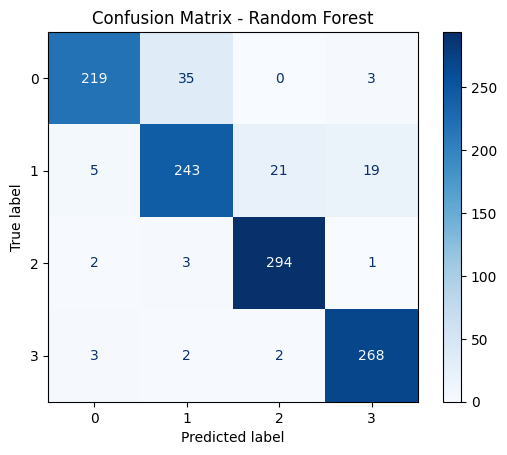

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")

plt.savefig("confusion_matrix_rf.png", dpi=300)

plt.show()

In [42]:
# install library
!pip install scikit-learn opencv-python matplotlib seaborn

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [47]:
base_path = "/content/Training"

for folder in os.listdir(base_path):
    print(folder, len(os.listdir(os.path.join(base_path, folder))))

notumor 1400
meningioma 1400
glioma 1400
pituitary 1400


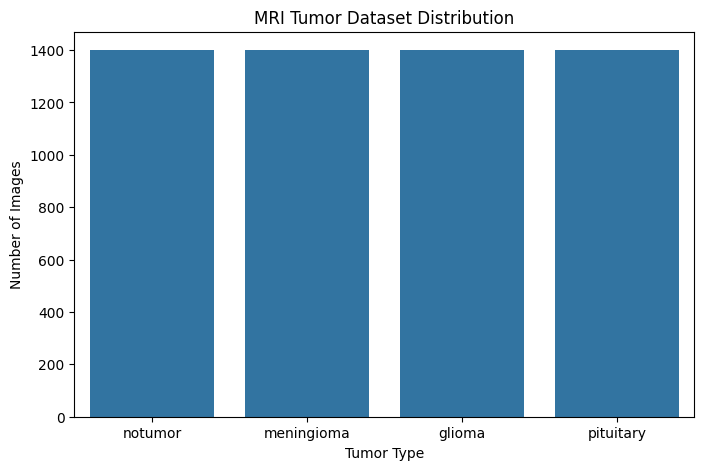

In [48]:
classes = os.listdir(base_path)

counts = []
for c in classes:
    counts.append(len(os.listdir(os.path.join(base_path, c))))

plt.figure(figsize=(8,5))
sns.barplot(x=classes, y=counts)
plt.title("MRI Tumor Dataset Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.show()

In [52]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 32.2 MB/s eta 0:00:00


In [63]:
!pip install -q tensorflow matplotlib seaborn pillow scikit-learn

In [64]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [60]:
train_dir = "/content/dataset/Training"